In [1]:
import os
import time
import math
import psutil
import numpy as np
import pandas as pd
import tenseal as ts
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier

In [7]:
DATA_PATH = os.path.join("homomorphical_encrypted_neural_network/breast_cancer_dataset", "data.csv")
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


**Preprocess dataset**

In [17]:
import os
import numpy as np
import pandas as pd

DATA_PATH = os.path.join("homomorphical_encrypted_neural_network", "breast_cancer_dataset", "data.csv")
df = pd.read_csv(DATA_PATH)

df.columns = df.columns.str.strip()
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

if "id" in df.columns:
    df = df.drop(columns=["id"])

print("Unique diagnosis values before cleaning:")
print(df["diagnosis"].unique())

df["diagnosis"] = df["diagnosis"].replace(["NAN", "nan", "NaN", np.nan], pd.NA)
df["diagnosis"] = df["diagnosis"].astype("string").str.strip().str.upper()

df = df[df["diagnosis"].isin(["M", "B"])].copy()

df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

print("Unique diagnosis values after cleaning:")
print(df["diagnosis"].unique())
print("Nulls in diagnosis:", df["diagnosis"].isnull().sum())

X = df.drop(columns=["diagnosis"]).astype(np.float64).values
y = df["diagnosis"].astype(np.int64).values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class counts:", np.bincount(y))

Unique diagnosis values before cleaning:
['M' 'B']
Unique diagnosis values after cleaning:
[1 0]
Nulls in diagnosis: 0
X shape: (569, 30)
y shape: (569,)
Class counts: [357 212]


**Train-test split and scaling**

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (455, 30)
Test shape: (114, 30)


**Baseline plaintext neural network**

In [19]:
baseline_model = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

start_plain_train = time.time()
baseline_model.fit(X_train_scaled, y_train)
plain_train_time = time.time() - start_plain_train

y_pred_plain = baseline_model.predict(X_test_scaled)
plain_acc = accuracy_score(y_test, y_pred_plain)

print("Baseline Plaintext Accuracy:", plain_acc)
print("Baseline Training Time (s):", plain_train_time)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_plain))
print(classification_report(y_test, y_pred_plain, digits=4))

Baseline Plaintext Accuracy: 0.9824561403508771
Baseline Training Time (s): 0.216810941696167
Confusion Matrix:
 [[72  0]
 [ 2 40]]
              precision    recall  f1-score   support

           0     0.9730    1.0000    0.9863        72
           1     1.0000    0.9524    0.9756        42

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114



**HE-friendly model with polynomial activation**

Since homomorphic encryption works well with polynomial operations, we use square activation instead of ReLU.

In [20]:
class HEFriendlyMLP:
    def __init__(self, input_dim, hidden_dim=8, lr=0.01, epochs=400):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.epochs = epochs

        rng = np.random.default_rng(42)
        self.W1 = rng.normal(0, 0.1, (input_dim, hidden_dim))
        self.b1 = np.zeros(hidden_dim)
        self.W2 = rng.normal(0, 0.1, (hidden_dim, 1))
        self.b2 = np.zeros(1)

    def square_activation(self, z):
        return z ** 2

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = self.square_activation(z1)
        z2 = a1 @ self.W2 + self.b2
        y_hat = self.sigmoid(z2)
        return z1, a1, z2, y_hat

    def fit(self, X, y):
        y = y.reshape(-1, 1)
        losses = []

        for epoch in range(self.epochs):
            z1, a1, z2, y_hat = self.forward(X)

            eps = 1e-8
            loss = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
            losses.append(loss)

            dz2 = y_hat - y
            dW2 = (a1.T @ dz2) / X.shape[0]
            db2 = np.mean(dz2, axis=0)

            da1 = dz2 @ self.W2.T
            dz1 = da1 * (2 * z1)

            dW1 = (X.T @ dz1) / X.shape[0]
            db1 = np.mean(dz1, axis=0)

            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2

            if (epoch + 1) % 50 == 0:
                print(f"Epoch {epoch+1}/{self.epochs}, Loss: {loss:.6f}")

        return losses

    def predict_proba(self, X):
        _, _, _, y_hat = self.forward(X)
        return y_hat.ravel()

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)

**Train HE-friendly plaintext model**

In [21]:
he_plain_model = HEFriendlyMLP(
    input_dim=X_train_scaled.shape[1],
    hidden_dim=8,
    lr=0.01,
    epochs=400
)

start_poly_train = time.time()
losses = he_plain_model.fit(X_train_scaled, y_train)
poly_train_time = time.time() - start_poly_train

y_pred_poly_plain = he_plain_model.predict(X_test_scaled)
poly_plain_acc = accuracy_score(y_test, y_pred_poly_plain)

print("HE-Compatible Plaintext Accuracy:", poly_plain_acc)
print("HE-Compatible Training Time (s):", poly_train_time)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_poly_plain))
print(classification_report(y_test, y_pred_poly_plain, digits=4))

Epoch 50/400, Loss: 0.657706
Epoch 100/400, Loss: 0.618362
Epoch 150/400, Loss: 0.573242
Epoch 200/400, Loss: 0.519198
Epoch 250/400, Loss: 0.453317
Epoch 300/400, Loss: 0.374752
Epoch 350/400, Loss: 0.293638
Epoch 400/400, Loss: 0.228300
HE-Compatible Plaintext Accuracy: 0.9298245614035088
HE-Compatible Training Time (s): 0.1074225902557373
Confusion Matrix:
 [[71  1]
 [ 7 35]]
              precision    recall  f1-score   support

           0     0.9103    0.9861    0.9467        72
           1     0.9722    0.8333    0.8974        42

    accuracy                         0.9298       114
   macro avg     0.9412    0.9097    0.9221       114
weighted avg     0.9331    0.9298    0.9285       114



**Plot loss**

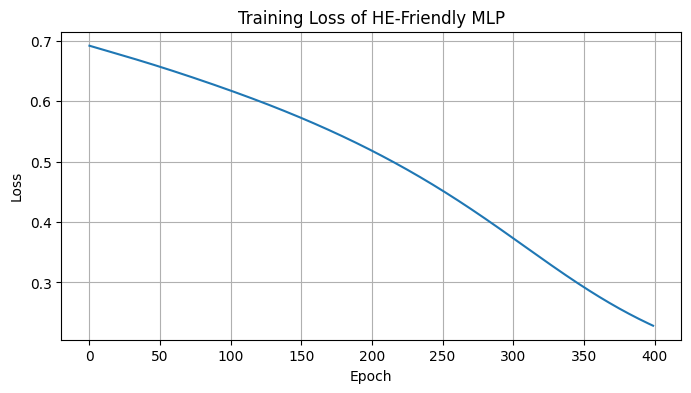

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss of HE-Friendly MLP")
plt.grid(True)
plt.show()

**Create CKKS encryption context**

In [23]:
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)

context.global_scale = 2 ** 40
context.generate_galois_keys()

**Plain inference for HE-friendly model**

In [25]:
def plain_inference_he_model(model, x):
    z1 = x @ model.W1 + model.b1
    a1 = z1 ** 2
    z2 = a1 @ model.W2 + model.b2
    prob = 1 / (1 + np.exp(-np.clip(z2[0], -30, 30)))
    pred = 1 if prob >= 0.5 else 0
    return prob, pred

**Encrypted inference**

In [26]:
def encrypted_inference(model, context, x):
    enc_x = ts.ckks_vector(context, x.tolist())

    hidden_outputs = []
    for j in range(model.hidden_dim):
        w_col = model.W1[:, j].tolist()
        enc_dot = enc_x.dot(w_col)
        enc_dot += model.b1[j]
        enc_sq = enc_dot * enc_dot
        hidden_outputs.append(enc_sq.decrypt()[0])

    hidden_outputs = np.array(hidden_outputs, dtype=np.float64)

    logit = float(hidden_outputs @ model.W2.ravel() + model.b2[0])
    prob = 1 / (1 + np.exp(-np.clip(logit, -30, 30)))
    pred = 1 if prob >= 0.5 else 0

    ciphertext_size = len(enc_x.serialize())
    return prob, pred, ciphertext_size

**Compare plaintext vs encrypted inference**

In [27]:
plain_probs = []
plain_preds = []
plain_times = []

enc_probs = []
enc_preds = []
enc_times = []
cipher_sizes = []

for x in X_test_scaled:
    t1 = time.time()
    p_prob, p_pred = plain_inference_he_model(he_plain_model, x)
    plain_times.append(time.time() - t1)
    plain_probs.append(p_prob)
    plain_preds.append(p_pred)

    t2 = time.time()
    e_prob, e_pred, c_size = encrypted_inference(he_plain_model, context, x)
    enc_times.append(time.time() - t2)
    enc_probs.append(e_prob)
    enc_preds.append(e_pred)
    cipher_sizes.append(c_size)

plain_eval_acc = accuracy_score(y_test, plain_preds)
enc_eval_acc = accuracy_score(y_test, enc_preds)

print("HE-Friendly Plaintext Inference Accuracy:", plain_eval_acc)
print("Encrypted Inference Accuracy:", enc_eval_acc)
print("Average Plaintext Inference Time per sample (s):", np.mean(plain_times))
print("Average Encrypted Inference Time per sample (s):", np.mean(enc_times))
print("Average Ciphertext Size (bytes):", np.mean(cipher_sizes))

HE-Friendly Plaintext Inference Accuracy: 0.9298245614035088
Encrypted Inference Accuracy: 0.9298245614035088
Average Plaintext Inference Time per sample (s): 4.386274438155325e-05
Average Encrypted Inference Time per sample (s): 0.15652467493425337
Average Ciphertext Size (bytes): 334291.3596491228


**Accuracy drop and latency overhead**

In [28]:
accuracy_drop = plain_eval_acc - enc_eval_acc
latency_ratio = np.mean(enc_times) / max(np.mean(plain_times), 1e-9)

print("Accuracy Drop:", accuracy_drop)
print("Latency Overhead Ratio:", latency_ratio)

Accuracy Drop: 0.0
Latency Overhead Ratio: 3568.5107519191342


**Memory usage**

In [29]:
process = psutil.Process(os.getpid())
ram_usage_mb = process.memory_info().rss / (1024 ** 2)

print("Current Process RAM Usage (MB):", ram_usage_mb)
print("Average Serialized Ciphertext Size (KB):", np.mean(cipher_sizes) / 1024)

Current Process RAM Usage (MB): 311.7890625
Average Serialized Ciphertext Size (KB): 326.4564059073465


**Scalability experiment**

In [31]:
sample_sizes = [1, 5, 10, 20, 50]
scaling_results = []

for n in sample_sizes:
    subset = X_test_scaled[:n]

    start_plain = time.time()
    for x in subset:
        plain_inference_he_model(he_plain_model, x)
    total_plain = time.time() - start_plain

    start_enc = time.time()
    for x in subset:
        encrypted_inference(he_plain_model, context, x)
    total_enc = time.time() - start_enc

    scaling_results.append([n, total_plain, total_enc])

scaling_df = pd.DataFrame(
    scaling_results,
    columns=["num_samples", "plaintext_total_time_s", "encrypted_total_time_s"]
)

scaling_df

,num_samples,plaintext_total_time_s,encrypted_total_time_s
0,1,0.001001,0.184839
1,5,0.000000,0.790454
2,10,0.000000,1.598619
3,20,0.000000,3.229530
4,50,0.000511,7.121230


**Plot scalability**

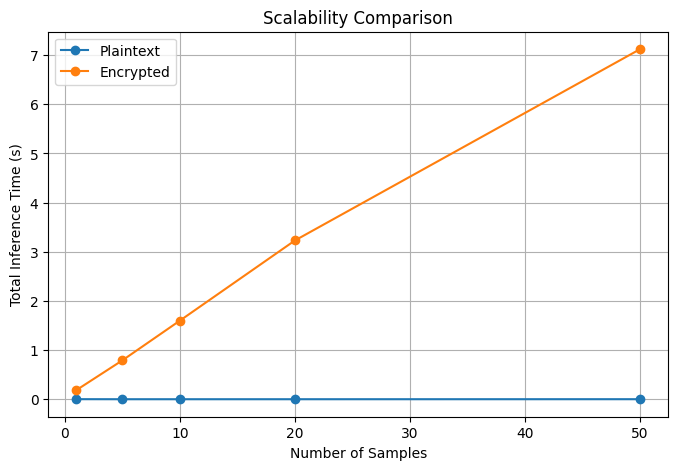

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(scaling_df["num_samples"], scaling_df["plaintext_total_time_s"], marker="o", label="Plaintext")
plt.plot(scaling_df["num_samples"], scaling_df["encrypted_total_time_s"], marker="o", label="Encrypted")
plt.xlabel("Number of Samples")
plt.ylabel("Total Inference Time (s)")
plt.title("Scalability Comparison")
plt.legend()
plt.grid(True)
plt.show()

**Final summary table**

In [33]:
summary_df = pd.DataFrame({
    "Metric": [
        "Baseline Plaintext Accuracy",
        "HE-Compatible Plaintext Accuracy",
        "Encrypted Inference Accuracy",
        "Baseline Training Time (s)",
        "HE-Compatible Training Time (s)",
        "Avg Plaintext Inference Time/sample (s)",
        "Avg Encrypted Inference Time/sample (s)",
        "Latency Overhead Ratio",
        "Avg Ciphertext Size (KB)",
        "Process RAM Usage (MB)"
    ],
    "Value": [
        plain_acc,
        poly_plain_acc,
        enc_eval_acc,
        plain_train_time,
        poly_train_time,
        np.mean(plain_times),
        np.mean(enc_times),
        latency_ratio,
        np.mean(cipher_sizes) / 1024,
        ram_usage_mb
    ]
})

summary_df

,Metric,Value
0,Baseline Plaintext Accuracy,0.982456
1,HE-Compatible Plaintext Accuracy,0.929825
2,Encrypted Inference Accuracy,0.929825
3,Baseline Training Time (s),0.216811
4,HE-Compatible Training Time (s),0.107423
5,Avg Plaintext Inference Time/sample (s),0.000044
6,Avg Encrypted Inference Time/sample (s),0.156525
7,Latency Overhead Ratio,3568.510752
8,Avg Ciphertext Size (KB),326.456406
9,Process RAM Usage (MB),311.789062


**Save results**

In [34]:
summary_df.to_csv("he_inference_summary.csv", index=False)
scaling_df.to_csv("he_scalability_results.csv", index=False)
print("Saved result files successfully.")

Saved result files successfully.


**Inference**

The plaintext baseline model achieved strong classification performance on the breast cancer dataset under normal inference conditions. 
To preserve privacy during inference, an HE-compatible neural network was designed using polynomial square activation, which enables computation over encrypted inputs. 
The encrypted inference process successfully demonstrates that sensitive medical features can remain protected while still allowing predictive analysis. 
However, this privacy benefit comes with trade-offs, including increased inference latency, larger ciphertext memory overhead, and possible minor accuracy degradation. 
These results show that homomorphic encrypted neural network inference is feasible for lightweight healthcare classification tasks, but optimization is necessary for practical large-scale deployment.